# Analisi preliminare del dataset DREAM

In [1]:
# Librerie Standard (Gestione File e Sistema)
import os
import glob
import json

# Librerie di gestione dei dati
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

# Librerie per i calcoli statistici
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import ttest_ind

# Librerie per la visualizzazione (grafici)
import matplotlib.pyplot as plt
import seaborn as sns

# Path del dataset locale
from config import DATA_PATH

## Caricamento del dataset

È stato definito il percorso al dataset (`DATA_PATH`) e contato il numero di sottocartelle, corrispondenti ai **61 bambini** inclusi nello studio.

In [2]:
os.listdir(DATA_PATH)
print(f"Totale bambini a cui sono state sottoposti le terapie: {len(os.listdir(DATA_PATH))}")

Totale bambini a cui sono state sottoposti le terapie: 61


## Individuazione delle sessioni

È stata effettuata una scansione dei file `.json` in tutte le sottocartelle di `DATA_PATH`, individuando **3121 sessioni di terapia** complessive.

In [3]:
search_pattern = os.path.join(DATA_PATH, "**", "*.json")
files = glob.glob(search_pattern, recursive=True)

if not files:
    print("Attenzione: Non è stato trovato alcun file .json in DATA_PATH. Controlla il percorso nel file config.")
else:
    print(f"Perfetto! Trovate {len(files)} sessioni pronte per l'elaborazione.")   
    
    for f in files[:3]:
        print(f"Trovato: {f}")

Perfetto! Trovate 3121 sessioni pronte per l'elaborazione.
Trovato: E:\0_PROGETTO_SF4B\dataset\User 10\User 10_0_diagnosis abilities_20170508_104619.961000.json
Trovato: E:\0_PROGETTO_SF4B\dataset\User 10\User 10_10_intervention 1_20170510_104335.477000.json
Trovato: E:\0_PROGETTO_SF4B\dataset\User 10\User 10_14_intervention 1_20170510_105016.362000.json


## Ispezione di un file JSON

Prima di procedere all'elaborazione massiva dell'intero dataset, eseguiamo un **test di lettura "grezza"** su un singolo file campione. Questo passaggio è fondamentale per verificare l'integrità dei dati e la coerenza dello schema JSON.

In [4]:
test_file = files[0]
print(f"Test sul file: {test_file}\n")

try:
    with open(test_file, 'r', encoding='utf-8') as f:
        raw_data = json.load(f)
    print("Chiavi trovate nel JSON:", raw_data.keys())
    print("\nContenuto campo 'condition':", raw_data.get('condition'))
    print("Contenuto campo 'participant':", raw_data.get('participant'))
except Exception as e:
    print(f"Errore critico nella lettura del JSON: {e}")

Test sul file: E:\0_PROGETTO_SF4B\dataset\User 10\User 10_0_diagnosis abilities_20170508_104619.961000.json

Chiavi trovate nel JSON: dict_keys(['$id', '$schema', 'ados', 'condition', 'eye_gaze', 'frame_rate', 'head_gaze', 'participant', 'skeleton', 'task', 'time'])

Contenuto campo 'condition': RET
Contenuto campo 'participant': {'ageInMonths': 66, 'gender': 'male', 'id': 10}


## Costruzione baseline e analisi descrittiva

L'obiettivo di questa fase è la **costruzione di una base dati coerente** che integri le caratteristiche anagrafiche dei partecipanti con il volume di attività registrato. Il processo inizia con un filtraggio selettivo dei file JSON: attraverso l'uso di un set di controllo, il sistema isola esclusivamente la prima occorrenza di ogni utente per **estrarre le informazioni di "baseline"** come l'età, il genere e i punteggi clinici ADOS, **evitando così ridondanze** nei dati anagrafici.

In [5]:
baseline_data = []
users_seen = set()

print(f"Inizio estrazione dati baseline da {len(files)} sessioni...")

for f_path in files:
    user_id = os.path.basename(f_path).split('_')[0]
    
    # Prendiamo solo la prima occorrenza di ogni utente per la baseline
    if user_id not in users_seen:
        try:
            with open(f_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
            
            record = {
                "User": user_id,
                "Condition": data.get('condition'),
                "Age_in_month": data.get('participant', {}).get('ageInMonths'),
                "Gender": data.get('participant', {}).get('gender'),
                "ADOS_Total": data.get('ados', {}).get('preTest', {}).get('total')
            }
            
            # Salviamo il record solo se è presente la condizione (RET o SHT)
            if record["Condition"]:
                baseline_data.append(record)
                users_seen.add(user_id)
                
        except Exception as e:
            continue

df_baseline = pd.DataFrame(baseline_data)

# Codifica binaria del genere
df_baseline['is_male'] = df_baseline['Gender'].map({'male': 1, 'female': 0})

all_user_ids = [os.path.basename(f).split('_')[0] for f in files]

sessions_count = pd.Series(all_user_ids).value_counts().reset_index()
sessions_count.columns = ['User', 'Session_Count']

df_final = pd.merge(df_baseline, sessions_count, on='User')

if not df_baseline.empty:
    print("\nANALISI BILANCIAMENTO BASELINE")
    
    # Creiamo la tabella aggregata
    tabella_unica = df_baseline.groupby('Condition').agg({
        'Condition': 'count',       # Conteggio dei soggetti
        'Age_in_month': 'mean',     # Media età
        'ADOS_Total': 'mean',       # Media punteggio ADOS
        'is_male': 'mean'           # Percentuale genere maschile
    })
    
    # Rinominiamo le colonne per chiarezza
    tabella_unica = tabella_unica.rename(columns={
        'Condition': 'N', 
        'is_male': '%_Male',
        'Age_in_month': 'Avg_Age',
        'ADOS_Total': 'Avg_ADOS'
    })
    
    print(tabella_unica)

Inizio estrazione dati baseline da 3121 sessioni...

ANALISI BILANCIAMENTO BASELINE
            N    Avg_Age   Avg_ADOS    %_Male
Condition                                    
RET        30  52.500000  13.833333  0.866667
SHT        31  53.258065  14.516129  0.838710


# Distribuzione dei Partecipanti (Count Plot)

Questo script genera un grafico a barre che mostra quanti bambini sono stati assegnati a ciascuna condizione. È il primo grafico fondamentale per descrivere la numerica del tuo studio.

C:\Users\utente\AppData\Local\Temp\ipykernel_23032\2594025906.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Condition', data=df_final, palette='Set2')


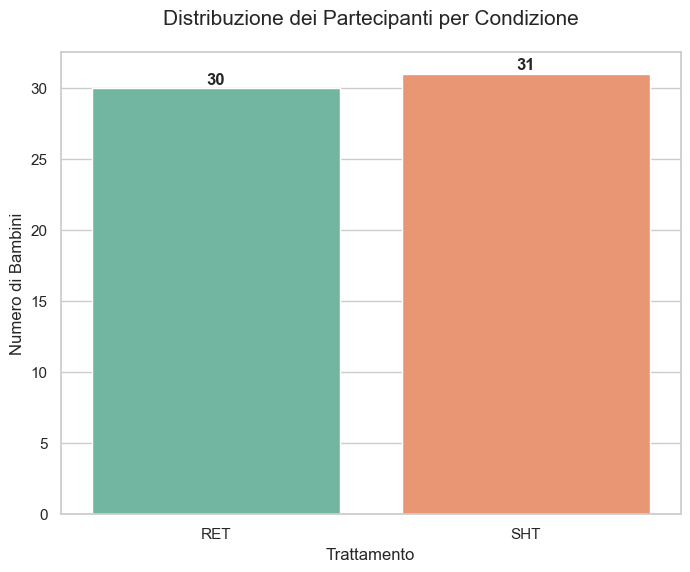

Grafico 1 (Distribuzione) salvato correttamente.


In [6]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

if not df_final.empty:
    if not os.path.exists('plots'):
        os.makedirs('plots')

    plt.figure(figsize=(8, 6))
    ax = sns.countplot(x='Condition', data=df_final, palette='Set2')
    
    plt.title('Distribuzione dei Partecipanti per Condizione', fontsize=15, pad=20)
    plt.ylabel('Numero di Bambini')
    plt.xlabel('Trattamento')

    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height() + 0.1), 
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.savefig('plots/01_distribuzione_trattamento.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Grafico 1 (Distribuzione) salvato correttamente.")

# Intensità del Trattamento (Boxplot + Stripplot)

Questo script analizza l'intensità della partecipazione (numero di sessioni completate) per ciascun gruppo. L'uso combinato di un boxplot e di uno stripplot permette di vedere sia le statistiche di sintesi (mediana e quartili) sia i singoli punti dato.

C:\Users\utente\AppData\Local\Temp\ipykernel_23032\307580421.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Condition', y='Session_Count', data=df_final, palette='Pastel1', width=0.5)


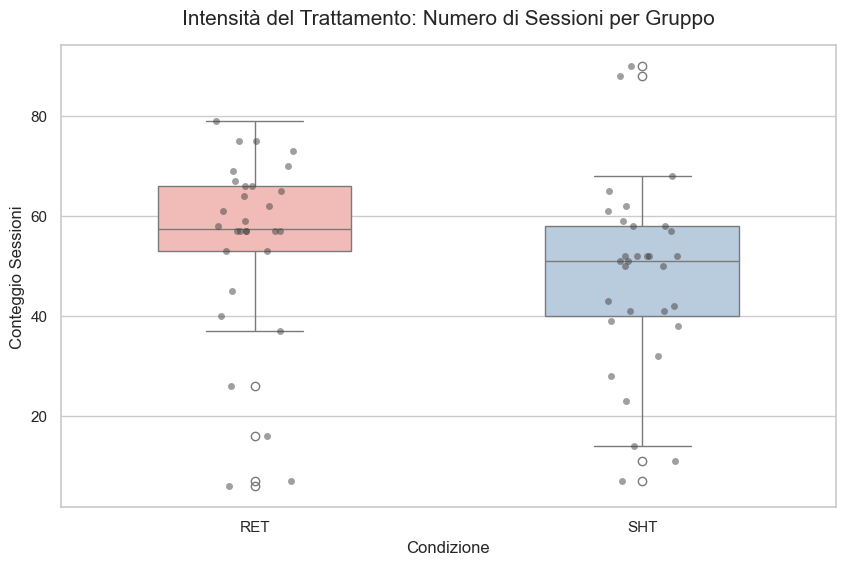

Grafico 2 (Intensità Sessioni) salvato correttamente.


In [7]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='Condition', y='Session_Count', data=df_final, palette='Pastel1', width=0.5)

sns.stripplot(x='Condition', y='Session_Count', data=df_final, color=".25", alpha=0.5, jitter=True)

plt.title('Intensità del Trattamento: Numero di Sessioni per Gruppo', fontsize=15, pad=15)
plt.ylabel('Conteggio Sessioni')
plt.xlabel('Condizione')

plt.savefig('plots/02_box_sessioni_per_gruppo.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grafico 2 (Intensità Sessioni) salvato correttamente.")

# Bilanciamento delle Covariate (KDE Plot)

Questo script è fondamentale per dimostrare la validità scientifica del tuo studio. Genera due grafici di densità di probabilità (KDE - Kernel Density Estimate) affiancati per confrontare l'Età e la Gravità Clinica (ADOS) tra i due gruppi.

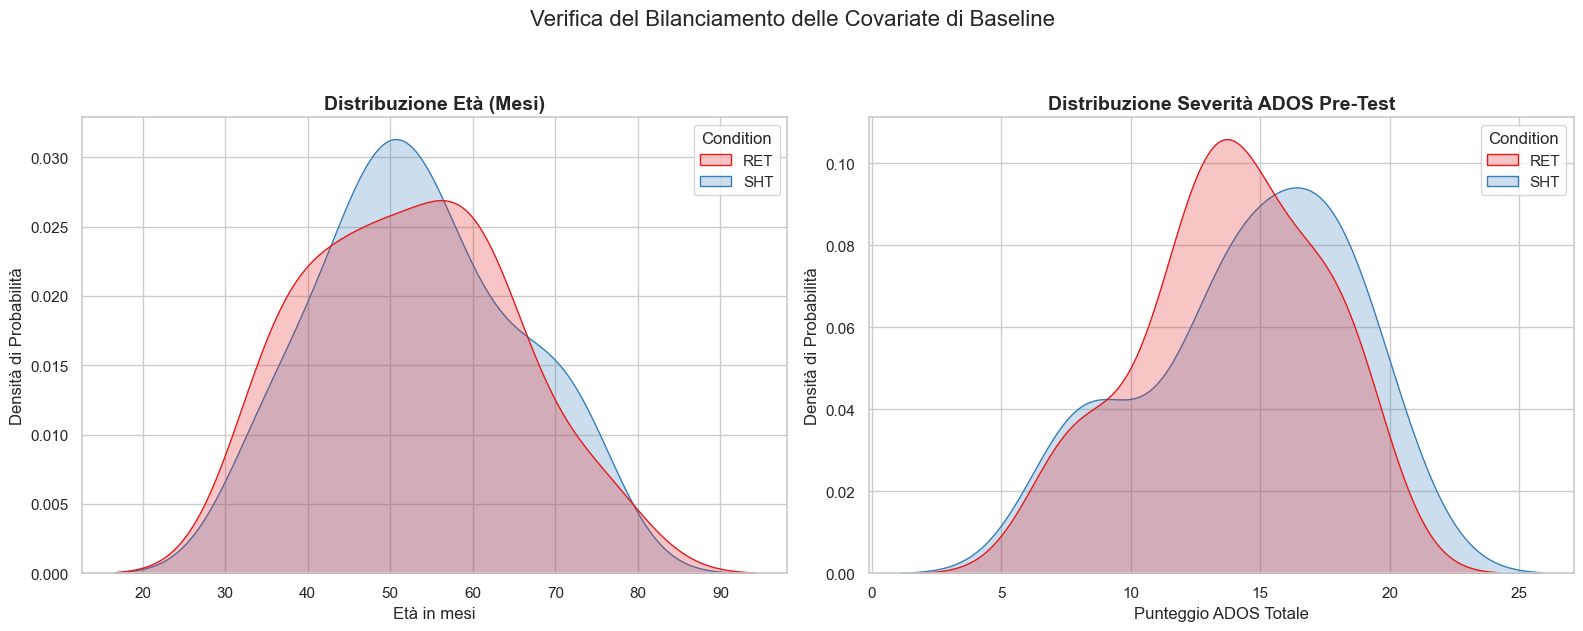

Grafico 3 (Bilanciamento Covariate) salvato correttamente.


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.kdeplot(data=df_final, x="Age_in_month", hue="Condition", fill=True, ax=ax1, palette='Set1', common_norm=False)
ax1.set_title('Distribuzione Età (Mesi)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Età in mesi', fontsize=12)
ax1.set_ylabel('Densità di Probabilità', fontsize=12)

sns.kdeplot(data=df_final, x="ADOS_Total", hue="Condition", fill=True, ax=ax2, palette='Set1', common_norm=False)
ax2.set_title('Distribuzione Severità ADOS Pre-Test', fontsize=14, fontweight='bold')
ax2.set_xlabel('Punteggio ADOS Totale', fontsize=12)
ax2.set_ylabel('Densità di Probabilità', fontsize=12)

plt.suptitle('Verifica del Bilanciamento delle Covariate di Baseline', fontsize=16, y=1.05)
plt.tight_layout()

plt.savefig('plots/03_bilanciamento_covariate.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grafico 3 (Bilanciamento Covariate) salvato correttamente.")

# Composizione di Genere

Questo script analizza la distribuzione di genere all'interno dei due gruppi. Utilizziamo un grafico a barre impilate (stacked bar chart) per visualizzare chiaramente la proporzione tra maschi e femmine in ciascuna condizione.

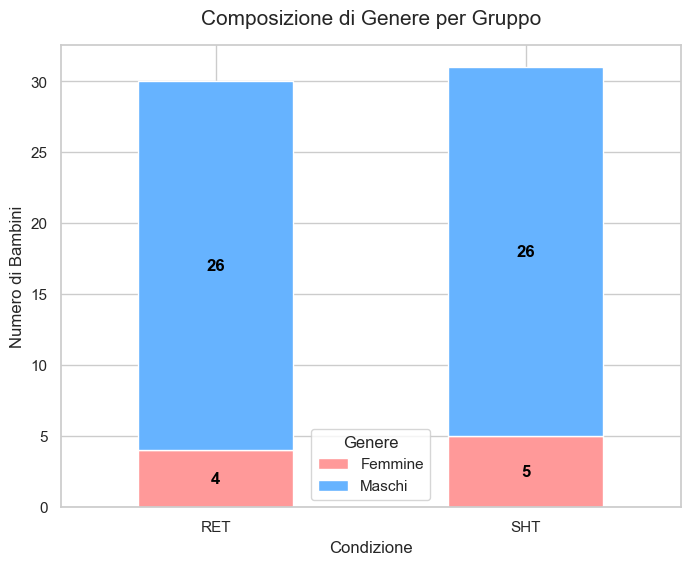


Tutti i grafici sono stati generati e salvati nella cartella 'plots/'.


In [9]:
gender_counts = df_final.groupby(['Condition', 'Gender']).size().unstack()
ax = gender_counts.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#ff9999','#66b3ff'])

plt.title('Composizione di Genere per Gruppo', fontsize=15, pad=15)
plt.ylabel('Numero di Bambini')
plt.xlabel('Condizione')
plt.xticks(rotation=0) # Mantiene le etichette RET/SHT orizzontali
plt.legend(title='Genere', labels=['Femmine', 'Maschi'])

for rect in ax.patches:
    height = rect.get_height()
    if height > 0:
        ax.text(rect.get_x() + rect.get_width()/2., 
                rect.get_y() + height/2., 
                f'{int(height)}', 
                ha='center', va='center', color='black', fontweight='bold')

plt.savefig('plots/04_composizione_genere.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTutti i grafici sono stati generati e salvati nella cartella 'plots/'.")

# Analisi Descrittiva dell'Intensità del Trattamento

Il successivo codice arricchisce il dataset aggiungendo l'informazione sul **numero totale di sessioni completate** da ogni bambino. Questa operazione culmina nella creazione di un DataFrame unificato che permette di confrontare istantaneamente i gruppi sperimentali.

In [10]:
df_final = pd.merge(df_baseline, sessions_count, on='User')

if not df_final.empty:
    print("\nSTATISTICHE SESSIONI PER GRUPPO")
    
    # Aggreghiamo tutto in un unico DataFrame
    session_stats = df_final.groupby('Condition')['Session_Count'].agg(
        N='count',
        Media='mean',
        Dev_Std='std',
        Min='min',
        Max='max'
    ).round(2)
    
    print(session_stats)
    
    # Calcolo della media globale
    media_totale = df_final['Session_Count'].mean()
    print(f"\nMedia sessioni totale per bambino: {media_totale:.2f}")


STATISTICHE SESSIONI PER GRUPPO
            N  Media  Dev_Std  Min  Max
Condition                              
RET        30  54.47    19.06    6   79
SHT        31  47.97    18.93    7   90

Media sessioni totale per bambino: 51.16


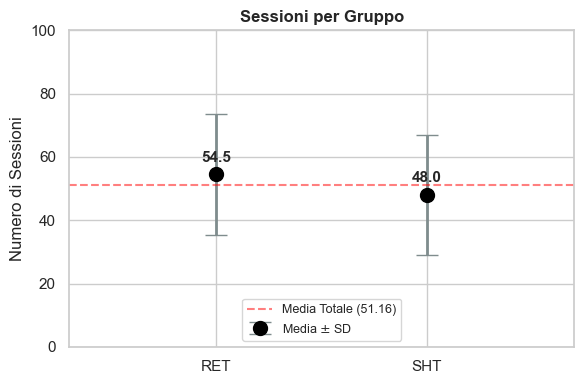

Grafico 5 generato dinamicamente e salvato in: plots/dotplot_sessioni_dinamico.png


In [11]:
categories = session_stats.index.tolist()
means = session_stats['Media'].tolist()
stds = session_stats['Dev_Std'].tolist()

media_globale = df_final['Session_Count'].mean()

plt.figure(figsize=(6, 4)) 
sns.set_theme(style="whitegrid")

plt.errorbar(x=categories, y=means, yerr=stds, 
             fmt='o', markersize=10, capsize=8, color='black', 
             ecolor='#7f8c8d', elinewidth=2, label='Media $\pm$ SD')

for i, m in enumerate(means):
    plt.text(i, m + 4, f'{m:.1f}', fontsize=11, fontweight='bold', ha='center')

plt.axhline(media_globale, color='red', linestyle='--', alpha=0.5, 
            label=f'Media Totale ({media_globale:.2f})')

plt.xlim(-0.7, 1.7) 

plt.title('Sessioni per Gruppo', fontsize=12, fontweight='bold')
plt.ylabel('Numero di Sessioni')
plt.ylim(0, 100)

plt.legend(loc='lower center', fontsize=9, frameon=True)

plt.tight_layout()

save_path = 'plots/dotplot_sessioni_dinamico.png'
plt.savefig(save_path, dpi=300)
plt.show()

print(f"Grafico 5 generato dinamicamente e salvato in: {save_path}")

## Campi di gaze e head orientation

Sono state ispezionate le chiavi dei campi `eye_gaze` e `head_gaze` per verificare la presenza delle componenti cartesiane (`rx`, `ry`, `rz`) necessarie al calcolo del proxy.

In [12]:
# File casuale (il primo in lista in questo caso)
sample = files[0]

with open(sample, 'r', encoding='utf-8') as f:
    data = json.load(f)
    
print(f"Eye Gaze fields: {list(data['eye_gaze'].keys())}")
print(f"Head Gaze fields: {list(data['head_gaze'].keys())}")

Eye Gaze fields: ['rx', 'ry', 'rz']
Head Gaze fields: ['rx', 'ry', 'rz']


## Dimensione delle serie temporali

È stata verificata la lunghezza della serie temporale `eye_gaze[]` e di `head_gaze[]` per avere un’idea del numero di frame disponibili per sessione.

In [13]:
# Verifica consistenza campionamento Eye Gaze
print(f"Eye Gaze Samples: {len(data['eye_gaze']['rx'])}, {len(data['eye_gaze']['ry'])}, {len(data['eye_gaze']['rz'])}")

# Verifica consistenza campionamento Head Gaze
print(f"Head Gaze Samples: {len(data['head_gaze']['rx'])}, {len(data['head_gaze']['ry'])}, {len(data['head_gaze']['rz'])}")

Eye Gaze Samples: 21459, 21459, 21459
Head Gaze Samples: 21459, 21459, 21459


## Funzione per il calcolo del proxy (AttentionScore)

È stata definita la funzione `compute_attention_score`, che:
- converte le componenti di `eye_gaze` e `head_gaze` in array numerici;
- rimuove frame con valori mancanti o non validi;
- normalizza i vettori;
- calcola la **cosine similarity** frame per frame;
- restituisce la media della similarità come proxy di joint attention per la sessione.

La **cosine similarity** misura il grado di allineamento tra due vettori (qui, direzione dello sguardo e orientamento della testa):  
valori vicini a 1 indicano che i due vettori puntano nella stessa direzione, mentre valori più bassi indicano minore coordinazione.

In [14]:
def compute_attention_score(data):
    try:
        # Estrazione e stacking dei vettori (X, Y, Z)
        eye = np.vstack([np.array(data['eye_gaze'][k], dtype=float) for k in ['rx', 'ry', 'rz']]).T
        head = np.vstack([np.array(data['head_gaze'][k], dtype=float) for k in ['rx', 'ry', 'rz']]).T
        
        # Filtro validità (valori finiti e campioni minimi)
        mask = np.isfinite(eye).all(axis=1) & np.isfinite(head).all(axis=1)
        eye, head = eye[mask], head[mask]
        if len(eye) < 10: return np.nan

        # Normalizzazione
        eye_n = eye / np.linalg.norm(eye, axis=1, keepdims=True)
        head_n = head / np.linalg.norm(head, axis=1, keepdims=True)
        
        # Calcolo Media Cosine Similarity
        return np.nanmean(np.sum(eye_n * head_n, axis=1))
    except:
        return np.nan

## Test preliminare del proxy su un sottoinsieme di sessioni

La funzione `compute_attention_score` è stata applicata alle prime 20 sessioni del dataset per verificare che:
- il calcolo del proxy funzionasse correttamente,
- i valori ottenuti fossero numerici e in un range plausibile (vicini a 1).

Questo passaggio ha costituito un controllo rapido prima di estendere il calcolo all’intero dataset.

In [15]:
scores = []

for f in files[:20]:
    with open(f, 'r', encoding='utf-8') as file:
        d = json.load(file)
    
    s = compute_attention_score(d)
    scores.append(s)

print(f"Scores calcolati: {len(scores)}")
print(f"Media parziale: {np.nanmean(scores):.3f}")

Scores calcolati: 20
Media parziale: 0.924


## Calcolo del proxy su tutte le sessioni e salvataggio

La funzione `compute_attention_score` è stata applicata a **tutte le 3121 sessioni**.
Per ciascuna sessione valida sono stati salvati:
- `User` (Riferimento bambino),
- `Condition` (RET/SHT),
- `AttentionScore` (proxy di joint attention).

L’elenco completo dei punteggi è stato memorizzato in un file CSV (`attention_scores.csv`) per evitare di dover ricalcolare il proxy in analisi successive.

In [16]:
# CONFIGURAZIONE
output_csv = "attention_scores.csv"

if os.path.exists(output_csv):
    df_scores = pd.read_csv(output_csv)
    print("Caricamento del file CSV completato.")
else:
    print(f"File '{output_csv}' non trovato. Inizio elaborazione dei {len(files)} file JSON...")
    
    records = []
    
    for f in tqdm(files, desc="Processing sessions"):
        try:
            with open(f, 'r', encoding='utf-8') as file:
                d = json.load(file)
            
            user = os.path.basename(f).split('_')[0]
            cond = d.get('condition')
            
            # Calcolo dell'AttentionScore
            score = compute_attention_score(d)
            
            # Salviamo solo se il punteggio è valido
            if not np.isnan(score):
                records.append({
                    "User": user,
                    "Condition": cond,
                    "AttentionScore": score
                })
                
        except Exception as e:
            # In caso di file corrotti, passiamo al successivo
            continue

    df_scores = pd.DataFrame(records)
    df_scores.to_csv(output_csv, index=False)
    print(f"Elaborazione terminata e file salvato in: {os.path.abspath(output_csv)}")

print("\nSTATISTICHE DATASET")
print(f"Totale sessioni valide: {len(df_scores)}")
print(f"Numero di utenti unici: {df_scores['User'].nunique()}")

print("\n - - - - - - - - - - - - - - - - - - - - \n")

print(df_scores.head())

Caricamento del file CSV completato.

STATISTICHE DATASET
Totale sessioni valide: 3049
Numero di utenti unici: 61

 - - - - - - - - - - - - - - - - - - - - 

      User Condition  AttentionScore
0  User 10       RET        0.927582
1  User 10       RET        0.912852
2  User 10       RET        0.904927
3  User 10       RET        0.937346
4  User 10       RET        0.937565


## Aggregazione del proxy a livello di bambino

I punteggi `AttentionScore` calcolati per ogni sessione sono stati mediati **per ciascun bambino (User) e condizione (RET/SHT)**, ottenendo un dataset con una sola osservazione per partecipante, da utilizzare per le analisi statistiche e causali successive.

In [17]:
df_user = df_scores.groupby(['User','Condition'])['AttentionScore'].mean().reset_index()

df_user.head()

,User,Condition,AttentionScore
0,User 10,RET,0.923005
1,User 11,SHT,0.910674
2,User 12,SHT,0.940660
3,User 13,SHT,0.935559
4,User 14,SHT,0.929839


## Statistiche descrittive del proxy per condizione

Sono state calcolate statistiche descrittive (media, deviazione standard, quartili, minimo e massimo) dell’`AttentionScore` separatamente per le condizioni **RET** e **SHT**, al fine di confrontare preliminarmente la distribuzione del proxy tra i due gruppi.

In [18]:
df_user.groupby('Condition')['AttentionScore'].describe()

,count,mean,std,min,25%,50%,75%,max
Condition,,,,,,,,
RET,30.0,0.928181,0.008825,0.915231,0.923287,0.927279,0.932054,0.952326
SHT,31.0,0.928762,0.010271,0.904021,0.924533,0.930337,0.935230,0.942660


C:\Users\utente\AppData\Local\Temp\ipykernel_23032\500316641.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Condition', y='AttentionScore', data=df,


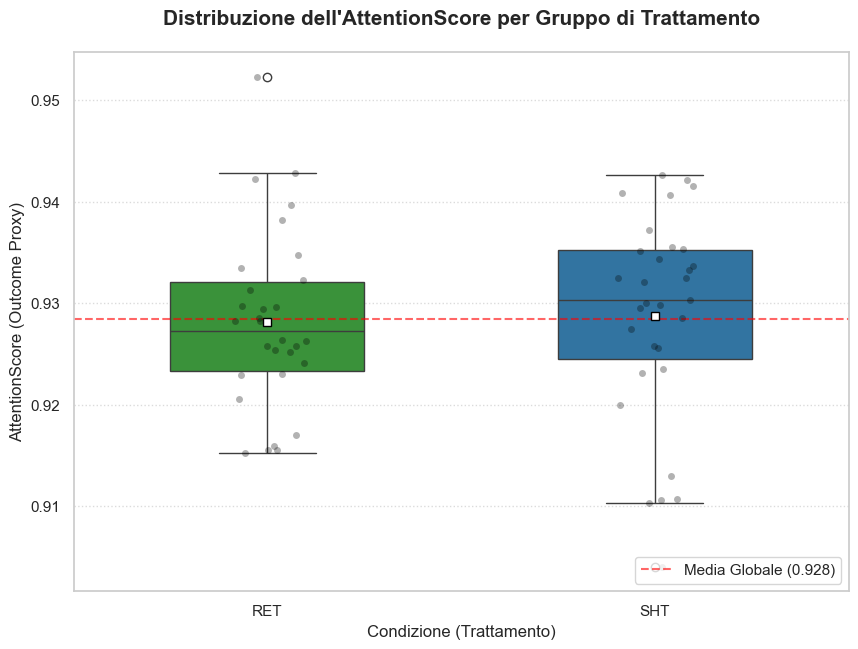

In [19]:
def plot_outcome_distribution(df):
    if not os.path.exists('plots'):
        os.makedirs('plots')
    
    plt.figure(figsize=(10, 7))
    palette = {'RET': '#2ca02c', 'SHT': '#1f77b4'}
    
    sns.boxplot(x='Condition', y='AttentionScore', data=df, 
                palette=palette, width=0.5, showmeans=True,
                meanprops={"marker":"s","markerfacecolor":"white", "markeredgecolor":"black"})
    
    sns.stripplot(x='Condition', y='AttentionScore', data=df, 
                  color='black', size=5, alpha=0.3, jitter=True)

    avg_score = df['AttentionScore'].mean()
    plt.axhline(y=avg_score, color='red', linestyle='--', alpha=0.6, label=f'Media Globale ({avg_score:.3f})')

    plt.title('Distribuzione dell\'AttentionScore per Gruppo di Trattamento', fontsize=15, fontweight='bold', pad=20)
    plt.xlabel('Condizione (Trattamento)', fontsize=12)
    plt.ylabel('AttentionScore (Outcome Proxy)', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(axis='y', linestyle=':', alpha=0.7)

    plt.savefig('plots/boxplot_attentionscore.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_outcome_distribution(df_user)

## Stima dell’ATE grezzo (differenza di medie)

È stato calcolato l’effetto medio del trattamento (ATE) come differenza tra la media dell’`AttentionScore` nel gruppo **RET** e quella nel gruppo **SHT**, ottenendo una prima stima descrittiva dell’effetto del robot sul proxy di joint attention.

In [20]:
mean_ret = df_user[df_user['Condition']=="RET"]['AttentionScore'].mean()
mean_sht = df_user[df_user['Condition']=="SHT"]['AttentionScore'].mean()

# Calcolo del differenziale (ATE)
ate = mean_ret - mean_sht

print(f"Media RET: {mean_ret:.4f}")
print(f"Media SHT: {mean_sht:.4f}")
print(f"ATE: {ate:.5f}")

Media RET: 0.9282
Media SHT: 0.9288
ATE: -0.00058


## Test di significatività (Welch t-test)

È stato eseguito un **t-test di Welch** per confrontare le medie dell’`AttentionScore` tra i gruppi **RET** e **SHT**.

Per verificare se la differenza osservata (ATE) sia statisticamente significativa e non dovuta al caso, **eseguiamo un T-test** per campioni indipendenti. Utilizziamo la **variante di Welch** *(equal_var=False)* che non assume l'omogeneità delle varianze tra i due gruppi, risultando più robusta.

In [21]:

ret = df_user[df_user['Condition']=="RET"]['AttentionScore']
sht = df_user[df_user['Condition']=="SHT"]['AttentionScore']

# Esecuzione del test di Welch
t_stat, p_val = ttest_ind(ret, sht, equal_var=False)

print(f"T-statistic: {t_stat:.5f}")
print(f"P-value: {p_val:.5f}")

T-statistic: -0.23717
P-value: 0.81336


## Costruzione del dataset analitico finale

Il dataset aggregato per bambino (`df_user`) è stato unito al dataset di baseline (`df_baseline`) tramite una join interna su `User` e `Condition`, ottenendo il dataset finale `df_full` contenente congiuntamente:
- il proxy di outcome (`AttentionScore`),
- la variabile di trattamento (`Condition`),
- le covariate di baseline (età, genere e ADOS pre-test).

Questo dataset costituisce la base per le analisi causali successive.

In [22]:
df_full = pd.merge(
    df_user, 
    df_baseline, 
    on=["User", "Condition"],
    how="inner"
)

print(f"Shape dataset consolidato: {df_full.shape}\n")
print(df_full.drop(columns=['is_male']).head())

Shape dataset consolidato: (61, 7)

      User Condition  AttentionScore  Age_in_month Gender  ADOS_Total
0  User 10       RET        0.923005            66   male          14
1  User 11       SHT        0.910674            53   male          20
2  User 12       SHT        0.940660            57   male          15
3  User 13       SHT        0.935559            53   male          20
4  User 14       SHT        0.929839            50   male          15


# Stima del Propensity Score

In questa sezione applichiamo l'**Inferenza Causale** per verificare l'assunzione di **Exchangeability** (Scambiabilità) tra il gruppo di trattamento (**RET** - Robot) e il gruppo di controllo (**SHT** - Umano). Utilizziamo una **Regressione Logistica** per calcolare la probabilità di ogni soggetto di appartenere al gruppo sperimentale (RET), basandoci sulle covariate di base: Età, Gravità (ADOS) e Genere.

In uno studio non perfettamente randomizzato, il *Propensity Score* bilancia i gruppi rendendo il confronto tra RET e SHT più equo, quasi come in un **esperimento controllato (RCT)**.

### Analisi dei Risultati (Interpretazione del Summary)
Per convalidare la robustezza dell'esperimento, osserviamo i seguenti parametri nel riepilogo del modello:

* **P-Value (> |z|)**: Se i valori sono alti (es. > 0.05), significa che nessuna delle caratteristiche basali ha influenzato significativamente l'assegnazione al gruppo.
* **Pseudo R-squared**: Un valore vicino allo zero indica che il modello non ha capacità predittiva.
* **Log-Likelihood / LLR p-value**: Testano se il modello è migliore di una scelta casuale.

In [23]:
df_final['target_treatment'] = df_final['Condition'].map({'RET': 1, 'SHT': 0})
formula = "target_treatment ~ Age_in_month + ADOS_Total + is_male"
model = smf.logit(formula, data=df_final).fit()
df_final['propensity_score'] = model.predict()

print("\nCOEFFICIENTI DEL MODELLO\n")
print(model.summary())

print("\nDISTRIBUZIONE PROBABILITÀ (Soggetti)\n")
print(df_final[['User', 'Condition', 'propensity_score']].head())

Optimization terminated successfully.
         Current function value: 0.687392
         Iterations 4

COEFFICIENTI DEL MODELLO

                           Logit Regression Results                           
Dep. Variable:       target_treatment   No. Observations:                   61
Model:                          Logit   Df Residuals:                       57
Method:                           MLE   Df Model:                            3
Date:                Tue, 10 Mar 2026   Pseudo R-squ.:                0.008110
Time:                        20:12:58   Log-Likelihood:                -41.931
converged:                       True   LL-Null:                       -42.274
Covariance Type:            nonrobust   LLR p-value:                    0.8766
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.7448      1.695      0.439      0.660      -2.578       4.

# Analisi della Sovrapposizione

Il codice genera un grafico di densità che confronta la distribuzione delle probabilità di assegnazione.

La sovrapposizione delle aree (verde per RET e blu per SHT) sta ad indicare **che i bambini nei due gruppi hanno caratteristiche di baseline (Età, ADOS, Genere) molto simili tra loro**. La linea tratteggiata in rosso (verticale allo 0.5) rappresenta il *lancio della moneta*: se le curve sono centrate vicino ad essa, si conferma che **non c'è stata una selezione intenzionale o un bias sistematico**. Infine, controllando le "code" della distribuzione, se si verificasse la situazione in cui una parte della curva verde si presenti dove non c'è quella blu (o viceversa), ciò indica che **che quei soggetti non hanno un "gemello" nell'altro gruppo** e dovrebbero essere teoricamente **esclusi dall'analisi causale**.

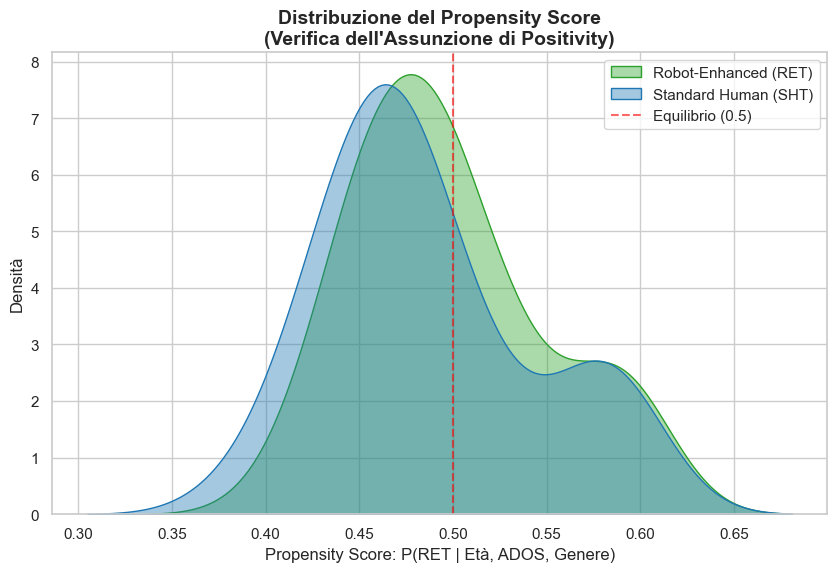

In [24]:
plt.figure(figsize=(10, 6))

sns.kdeplot(data=df_final[df_final['target_treatment'] == 1], x='propensity_score', 
            fill=True, label='Robot-Enhanced (RET)', color='#2ca02c', alpha=0.4)

sns.kdeplot(data=df_final[df_final['target_treatment'] == 0], x='propensity_score', 
            fill=True, label='Standard Human (SHT)', color='#1f77b4', alpha=0.4)

plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.6, label='Equilibrio (0.5)')

plt.title('Distribuzione del Propensity Score\n(Verifica dell\'Assunzione di Positivity)', fontsize=14, fontweight='bold')
plt.xlabel('Propensity Score: P(RET | Età, ADOS, Genere)')
plt.ylabel('Densità')
plt.legend()

# Esportazione
plt.savefig('plots/common_support.png', dpi=300)
plt.show()

# Consolidamento Dataset per Inferenza Causale

Il DataFrame finale df_forDL_ready è strutturato per **modelli di Deep Learning avanzati**, integrando outcome comportamentali, covariate cliniche e punteggi di propensione.

In [25]:
nome_file = "df_final.xlsx"

# Uniamo l'outcome alle covariate e al conteggio sessioni
df_forDL_ready = pd.merge(
    df_full[['User', 'Condition', 'AttentionScore']], 
    df_final[['User', 'Condition', 'Age_in_month', 'ADOS_Total', 'is_male', 'Session_Count', 'propensity_score', 'target_treatment']], 
    on=['User', 'Condition'], 
    how='inner'
)

df_forDL_ready.to_excel(nome_file, index=False)
print(f"Dataset salvato con successo nel file 'df_forDL_ready.csv': {df_forDL_ready.shape[0]} righe, {df_forDL_ready.shape[1]} colonne.")

Dataset salvato con successo nel file 'df_forDL_ready.csv': 61 righe, 9 colonne.
